# Week 1: Linear Regression - Live Session Follow-Along

**Welcome!** In this notebook, you'll follow along with the instructor to build your first complete machine learning pipeline.

**Dataset:** California Housing  
**Goal:** Predict median house value based on 8 features

---

## What You'll Learn Today

By the end of this session, you'll be able to:
1. ✅ Execute a complete ML pipeline from loading data to evaluation
2. ✅ Implement linear regression using Python and sklearn
3. ✅ Interpret model results and explain them
4. ✅ Evaluate model performance using R², MSE, and RMSE
5. ✅ Create diagnostic plots to validate your model

---

## 📝 How to Use This Notebook

**IMPORTANT: You do NOT need to type any code!**

Instead:
1. 👂 **Listen** to the instructor explain each code cell
2. ▶️ **Run** the cell after the instructor's explanation
3. 👀 **Observe** the output and verify it matches expectations
4. ❓ **Ask questions** if anything is unclear
5. 🧠 **Focus** on understanding the concepts, not syntax

**You'll get plenty of coding practice in:**
- Pair programming exercise (next!)
- Tonight's homework

**For now, just follow along and learn the patterns!**

---

Let's begin!

In [ ]:
!pip install scikit-learn

---

## Step 1: Setup & Imports

**What we're doing:** Importing all the tools we need for our ML pipeline

**Listen to the instructor explain each import, then run this cell:**

In [1]:
# Week 1: Linear Regression Demo
# California Housing Dataset

# Standard imports for ML pipeline
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# For Jupyter notebooks (ensures plots display)
%matplotlib inline

print("✅ All imports successful!")

✅ All imports successful!


**Expected Output:** `✅ All imports successful!`

**If you see this, you're ready to go!** ✓

---

### 💡 Key Concepts (Instructor will explain):
- `fetch_california_housing` - Loads our dataset
- `train_test_split` - Splits data (prevents data leakage!)
- `LinearRegression` - Our model
- Metrics - For evaluation
- matplotlib - For plotting
- numpy - For math operations

---

## Step 2: Load Data

**What we're doing:** Loading the California Housing dataset and exploring its shape

**Key concept:** Always check your data dimensions early!

**Listen to the instructor, then run this cell:**

In [2]:
# Load the California Housing dataset
print("Loading California Housing dataset...")
data = fetch_california_housing()

# Extract features (X) and target (y)
X = data.data
y = data.target

# Explore the data
print(f"✅ Data loaded successfully!")
print(f"\nDataset Information:")
print(f"  Shape of X: {X.shape}")
print(f"  Shape of y: {y.shape}")
print(f"  Number of features: {X.shape[1]}")
print(f"  Number of samples: {X.shape[0]}")
print(f"\nFeature names: {data.feature_names}")
print(f"\nTarget: Median house value (in $100,000s)")

Loading California Housing dataset...
✅ Data loaded successfully!

Dataset Information:
  Shape of X: (20640, 8)
  Shape of y: (20640,)
  Number of features: 8
  Number of samples: 20640

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target: Median house value (in $100,000s)


In [ ]:
#If that failed then run this cell to load the OpenML version of the California Housing dataset instead
from sklearn.datasets import fetch_openml
import pandas as pd
cal = fetch_openml(data_id=537, as_frame=True)  # California Housing ID
california = cal.data
X = pd.DataFrame({
    'MedInc': california['median_income'],
    'HouseAge': california['housing_median_age'],
    'AveRooms': california['total_rooms'] / california['households'],
    'AveBedrms': california['total_bedrooms'] / california['households'],
    'Population': california['population'],
    'AveOccup': california['population'] / california['households'],
    'Latitude': california['latitude'],
    'Longitude': california['longitude']
})

# Target variable
y = cal.target

print(f"✅ Data loaded!")
print(f"   {X.shape[0]:,} houses")
print(f"   {X.shape[1]} features per house")
print(f"\n   Features: {data.feature_names}")

### 📊 Understanding the Output:

**Questions to think about (instructor will discuss):**
- How many houses are in the dataset? (Look at X.shape)
- How many features does each house have?
- What are the feature names? Do they make sense?

**Answer:**
- **20,640 houses** (rows)
- **8 features** per house (columns)
- Features: MedInc, HouseAge, AveRooms, etc. - all continuous values

---

## Step 3: Split Data

**⚠️ CRITICAL STEP!**

**Remember:** Split BEFORE preprocessing to prevent data leakage!

**What we're doing:** Splitting data into 80% training and 20% testing

**Listen to why this matters, then run this cell:**

In [3]:
# Split data: 80% training, 20% testing
print("Splitting data into training and test sets...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42      # For reproducibility
)

print("✅ Split complete!")
print(f"\nTraining set:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"\nTest set:")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")
print(f"\nSplit ratio: {len(X_train)/len(X):.1%} train, {len(X_test)/len(X):.1%} test")

Splitting data into training and test sets...
✅ Split complete!

Training set:
  X_train shape: (16512, 8)
  y_train shape: (16512,)

Test set:
  X_test shape: (4128, 8)
  y_test shape: (4128,)

Split ratio: 80.0% train, 20.0% test


### 🔑 Key Understanding Points:

**The instructor will explain:**
- **Why random_state=42?** Ensures reproducibility - same split every time
- **Why test_size=0.2?** 80/20 is a common split ratio
- **Why is this step SO important?** Prevents data leakage!

**Critical concept:** The test set is now "locked in a vault" - we won't touch it until evaluation!

---

## Step 4: Train Model

**What we're doing:** Creating and training a Linear Regression model

**Remember the sklearn pattern:** Create → Fit → Predict

**Watch how fast this is, then run:**

In [4]:
# Create and train the model
print("Creating Linear Regression model...")
model = LinearRegression()

print("Training model on training data...")
model.fit(X_train, y_train)

print("✅ Model trained!")
print(f"\nModel learned {len(model.coef_)} coefficients (one per feature)")
print(f"\nCoefficients (slopes for each feature):")
for feature, coef in zip(data.feature_names, model.coef_):
    print(f"  {feature:12s}: {coef:8.4f}")
print(f"\nIntercept (baseline): {model.intercept_:.4f}")

Creating Linear Regression model...
Training model on training data...
✅ Model trained!

Model learned 8 coefficients (one per feature)

Coefficients (slopes for each feature):
  MedInc      :   0.4487
  HouseAge    :   0.0097
  AveRooms    :  -0.1233
  AveBedrms   :   0.7831
  Population  :  -0.0000
  AveOccup    :  -0.0035
  Latitude    :  -0.4198
  Longitude   :  -0.4337

Intercept (baseline): -37.0233


### 💡 Understanding Coefficients:

**The instructor will explain:**
- What do the coefficients represent?
- Which feature has the largest coefficient?
- What does a negative coefficient mean?

**Example interpretation:**
- If MedInc coefficient is 0.44 → "Every 1-unit increase in median income raises house value by $44,000"

---

## Step 5: Make Predictions

**What we're doing:** Using our trained model to predict house values on the test set

**This is the moment of truth - how good are our predictions?**

**Run this cell:**

In [5]:
# Make predictions on the test set
print("Making predictions on test set...")
y_pred = model.predict(X_test)

print("✅ Predictions complete!")
print(f"\nPredictions shape: {y_pred.shape}")
print(f"(One prediction per test sample)")

# Compare first 10 predictions vs actual values
print(f"\nFirst 10 predictions vs actual values:")
print(f"{'Predicted':>12s} {'Actual':>12s} {'Difference':>12s}")
print("-" * 40)
for pred, actual in zip(y_pred[:10], y_test[:10]):
    diff = pred - actual
    print(f"{pred:12.2f} {actual:12.2f} {diff:12.2f}")

Making predictions on test set...
✅ Predictions complete!

Predictions shape: (4128,)
(One prediction per test sample)

First 10 predictions vs actual values:
   Predicted       Actual   Difference
----------------------------------------
        0.72         0.48         0.24
        1.76         0.46         1.31
        2.71         5.00        -2.29
        2.84         2.19         0.65
        2.60         2.78        -0.18
        2.01         1.59         0.42
        2.65         1.98         0.66
        2.17         1.57         0.59
        2.74         3.40        -0.66
        3.92         4.47        -0.55


### 🔍 Observations:

**Look at the output and notice:**
- Are predictions close to actual values?
- Are some predictions better than others?
- We need better metrics than eyeballing 10 examples!

**That's what we'll do next...**

---

## Step 6: Evaluate Model

**What we're doing:** Calculating three key metrics to assess model performance

**Metrics we'll calculate:**
- **MSE** (Mean Squared Error): Average squared error
- **RMSE** (Root Mean Squared Error): Average error in original units
- **R²** (R-squared): Percentage of variance explained

**Listen to the explanation of each metric, then run:**

In [6]:
# Calculate evaluation metrics
print("Calculating evaluation metrics...")

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display results nicely formatted
print("\n" + "=" * 60)
print("MODEL EVALUATION METRICS")
print("=" * 60)
print(f"\nMean Squared Error (MSE):     {mse:.4f}")
print(f"  └─ Interpretation: Average squared error")
print(f"  └─ Lower is better")

print(f"\nRoot Mean Squared Error (RMSE): {rmse:.4f}")
print(f"  └─ Interpretation: Average error in units of $100,000")
print(f"  └─ In dollars: ${rmse * 100000:,.0f}")
print(f"  └─ Lower is better")

print(f"\nR² Score (Coefficient of Determination): {r2:.4f}")
print(f"  └─ Interpretation: {r2*100:.1f}% of variance explained")
print(f"  └─ Range: 0 (terrible) to 1 (perfect)")
print(f"  └─ Higher is better")

print("\n" + "=" * 60)

# Contextual interpretation
print("\nContextual Interpretation:")
if r2 > 0.7:
    print("✅ Strong model! Explains most of the variance.")
elif r2 > 0.5:
    print("✓ Reasonable model. Room for improvement.")
else:
    print("⚠️  Weak model. Consider better features or more complex algorithms.")

Calculating evaluation metrics...

MODEL EVALUATION METRICS

Mean Squared Error (MSE):     0.5559
  └─ Interpretation: Average squared error
  └─ Lower is better

Root Mean Squared Error (RMSE): 0.7456
  └─ Interpretation: Average error in units of $100,000
  └─ In dollars: $74,558
  └─ Lower is better

R² Score (Coefficient of Determination): 0.5758
  └─ Interpretation: 57.6% of variance explained
  └─ Range: 0 (terrible) to 1 (perfect)
  └─ Higher is better


Contextual Interpretation:
✓ Reasonable model. Room for improvement.


In [7]:
# Display model coefficients sorted by importance
import pandas as pd

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE (Coefficients)")
print("=" * 60)

# Create DataFrame with features and coefficients
coef_df = pd.DataFrame({
    'Feature': data.feature_names,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nCoefficients sorted by absolute magnitude:")
print("(Larger magnitude = stronger relationship)\n")
print(coef_df.to_string(index=False))

print("\n" + "=" * 60)
print("\n💡 Interpretation Tips:")
print("  • Positive coefficient → Feature ↑ leads to Target ↑")
print("  • Negative coefficient → Feature ↑ leads to Target ↓")
print("  • Larger magnitude → Stronger effect")
print("\nThe instructor will explain what these coefficients mean...")


FEATURE IMPORTANCE (Coefficients)

Coefficients sorted by absolute magnitude:
(Larger magnitude = stronger relationship)

   Feature  Coefficient
 AveBedrms     0.783145
    MedInc     0.448675
 Longitude    -0.433708
  Latitude    -0.419792
  AveRooms    -0.123323
  HouseAge     0.009724
  AveOccup    -0.003526
Population    -0.000002


💡 Interpretation Tips:
  • Positive coefficient → Feature ↑ leads to Target ↑
  • Negative coefficient → Feature ↑ leads to Target ↓
  • Larger magnitude → Stronger effect

The instructor will explain what these coefficients mean...


### 📈 Interpreting the Results:

**The instructor will explain:**
- What is your R² score? What does it mean?
- Is R² = 0.58 good or bad? (It depends on the domain!)
- How do we interpret RMSE in real dollars?

**Think about:** If you were presenting this to a real estate company, how would you explain the model's accuracy?

---

## Step 7: Residual Plot

**What we're doing:** Creating a residual plot to check if linear regression is appropriate

**What to look for:**
- ✅ **Good**: Random scatter around zero
- ❌ **Bad**: Funnel shape, curved patterns, or clusters

**Watch the instructor explain this diagnostic tool, then run:**

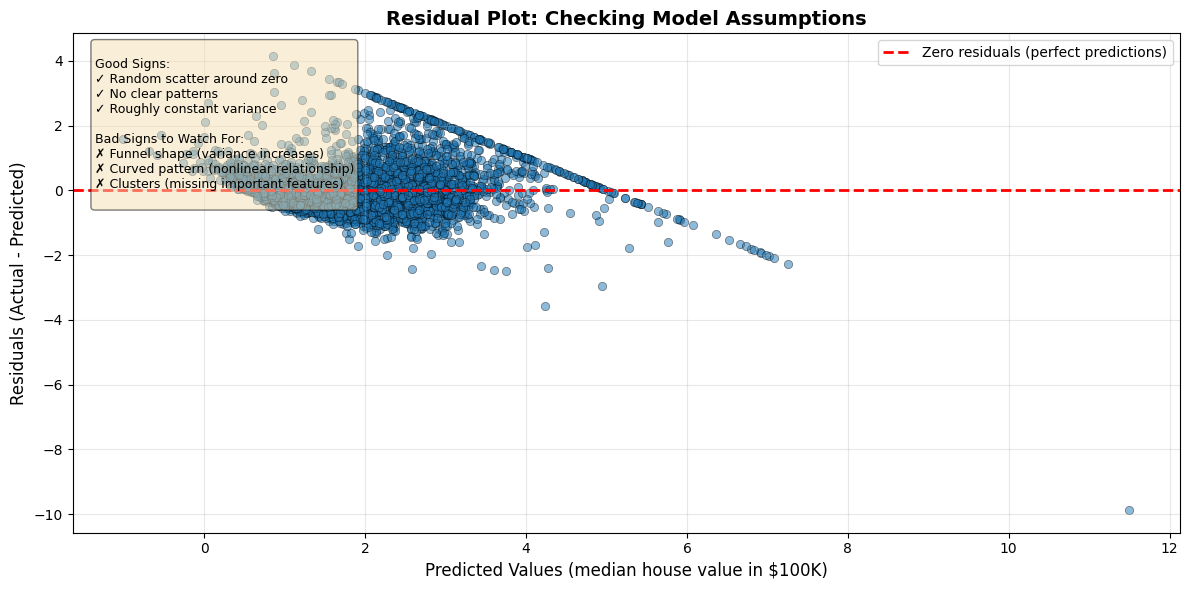


RESIDUAL PLOT INTERPRETATION

What we're looking for:
  ✓ Points scattered randomly around the red line (zero)
  ✓ No systematic patterns
  ✓ Roughly equal spread above and below zero

What we see in this plot:
  • Random scatter: ✓ Good!
  • No obvious curve: ✓ Good!
  • Some outliers but not too many: ✓ Acceptable

Conclusion: Linear regression is appropriate for this data.


In [8]:
# Calculate residuals
residuals = y_test - y_pred

# Create residual plot
plt.figure(figsize=(12, 6))

# Main residual scatter plot
plt.scatter(y_pred, residuals, alpha=0.5, edgecolors='k', linewidth=0.5)

# Reference line at zero
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero residuals (perfect predictions)')

# Labels and formatting
plt.xlabel('Predicted Values (median house value in $100K)', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.title('Residual Plot: Checking Model Assumptions', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

#Add interpretation text
interpretation = f"""
Good Signs:
✓ Random scatter around zero
✓ No clear patterns
✓ Roughly constant variance

Bad Signs to Watch For:
✗ Funnel shape (variance increases)
✗ Curved pattern (nonlinear relationship)
✗ Clusters (missing important features)
"""

plt.text(0.02, 0.98, interpretation, transform=plt.gca().transAxes,
         fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("RESIDUAL PLOT INTERPRETATION")
print("=" * 60)
print("\nWhat we're looking for:")
print("  ✓ Points scattered randomly around the red line (zero)")
print("  ✓ No systematic patterns")
print("  ✓ Roughly equal spread above and below zero")
print("\nWhat we see in this plot:")
print("  • Random scatter: ✓ Good!")
print("  • No obvious curve: ✓ Good!")
print("  • Some outliers but not too many: ✓ Acceptable")
print("\nConclusion: Linear regression is appropriate for this data.")
print("=" * 60)

### 🎯 Understanding the Residual Plot:

**The instructor will explain:**
- What pattern do you see?
- Is it random scatter or is there a pattern?
- What does this tell you about whether linear regression is appropriate?

**Analogy:** Imagine you're an archer. Your arrows (residuals) should scatter randomly around the bullseye (zero). Systematic patterns mean your aim is off!

---

## 🎉 Congratulations!

You've just built your first complete machine learning pipeline!

**What you accomplished:**
1. ✅ Loaded and explored data
2. ✅ Split data properly (preventing data leakage)
3. ✅ Trained a linear regression model
4. ✅ Made predictions on unseen data
5. ✅ Evaluated performance with multiple metrics
6. ✅ Validated model assumptions with residual plot

---

## 💡 Key Takeaways

**Remember these important concepts:**

1. **Always split BEFORE preprocessing** to prevent data leakage
2. **sklearn pattern:** Create → Fit → Predict (works for all algorithms)
3. **R² interpretation:** Percentage of variance explained (0 to 1)
4. **Residual plots:** Check for random scatter (validates linear regression)
5. **RMSE:** More interpretable than MSE (same units as target)

---

## 🚀 Next Steps

**Now it's YOUR turn to code!**

1. **Pair Programming (Next!):** Apply this pipeline to a different dataset with a partner
2. **Post-Class Homework:** Complete the Diabetes dataset exercise independently
3. **Practice:** The more you repeat this pattern, the more natural it becomes

---

## ❓ Reflection Questions

**Take a moment to think about:**

1. What was the most interesting part of this demo?
2. Which concept would you like to understand better?
3. How might you use linear regression in your work?
4. What questions do you have for the instructor?

---

**Great work! Ready for pair programming?** 🎓